# Augmented Reality with Python 3 and OpenCV 4.2

A basic code of an **Augmented Reality** system that adds a 3D model aligned (orientation and translation) to a predefined flat surface. Matrices are pre-calculated from here: ([Augmented Reality 101](https://github.com/mafda/augmented_reality_101)). 

> For more details read this complete [post](https://bitesofcode.wordpress.com/2017/09/12/augmented-reality-with-python-and-opencv-part-1/), or this [book](http://programmingcomputervision.com/downloads/ProgrammingComputerVision_CCdraft.pdf).

## References

* JE Solem, *Programming Computer Vision with Python: Tools and algorithms for analyzing images*. O'Reilly Media, Inc.
* [Programming Computer Vision with Python](http://programmingcomputervision.com/)
* [Open source Python module for computer vision ](https://github.com/jesolem/PCV)
* [Augmented reality with Python and OpenCV](https://bitesofcode.wordpress.com/2017/09/12/augmented-reality-with-python-and-opencv-part-1/)
* [augmented-reality](https://github.com/juangallostra/augmented-reality)
* [OBJFileLoader](https://github.com/yarolig/OBJFileLoader)


## Prepare data

Include libraries in Python, such as OpenCV, Numpy, and Matplotlib.

In [4]:
import cv2
import numpy as np
import math
%matplotlib inline
import matplotlib.pyplot as plt

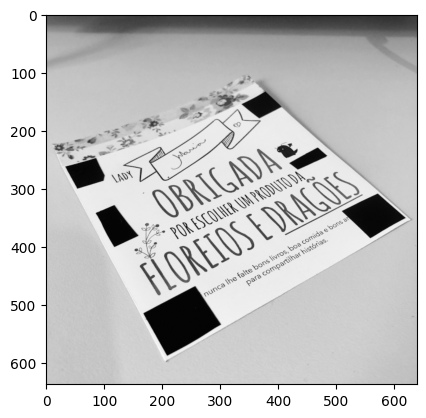

In [5]:
# Load the source image and convert it to gray scale
sourceImage = cv2.imread('../img/sourceImage_04.jpg', 0) 

# Show image
plt.imshow(sourceImage, cmap='gray')
plt.show()

## Camera model


### Camera parameters

[Pinhole](https://en.wikipedia.org/wiki/Pinhole_camera_model) camera model is a widely used camera model that describes the mathematical relationship between the coordinates of a 3D point and its projection onto the image plane (both expressed in homogeneous coordinates) as $\lambda x = PX$, where $P$ is called the camera matrix (or projection matrix), the 3D point $X$ has four elements in homogeneous coordinates, $X=[X, Y, Z, W]$, and the scalar $\lambda$ is the inverse depth of the 3D point.

The camera matrix can be decomposed as $P=K[R|t]$, where $R$ is a rotation matrix describing the orientation of the camera, $t$ a 3D translation vector describing the position of the camera center, and the intrinsic calibration matrix $K$ describing the projection properties of the camera.

The calibration matrix or intrinsic parameters matrix is written as:

$ K =  \begin{bmatrix} f & 0 & c_x \\  0 & f & c_y \\ 0 & 0 & 1 \end{bmatrix} $

### 3D Object

We are using simple models in format [Wavefront .obj](https://en.wikipedia.org/wiki/Wavefront_.obj_file) from [claro.io](https://clara.io), and [OBJFileLoader](https://github.com/yarolig/OBJFileLoader) loads the 3D models provided by [Pygame](https://www.pygame.org/wiki/OBJFileLoader). 

After loading the 3D model, a function is implemented to read the data and project it to the top of the video frame with the projection matrix that was obtained. To do this, we take all the points used to define the model and multiply it by the projection matrix.

In [15]:
from objloader_simple import *

# Load 3D model from OBJ file
#obj = OBJ('../models/chair.obj', swapyz=True)
obj = OBJ('../models/chair.obj')

In [16]:
# project cube or model
def render(img, obj, P, model, color=False):

    vertices = obj.vertices
    scale_matrix = np.eye(3) * 5
    h, w, c = model.shape

    for face in obj.faces:
        face_vertices = face[0]
        points = np.array([vertices[vertex - 1] for vertex in face_vertices])
        points = np.dot(points, scale_matrix)
        # render model in the middle of the reference surface. To do so,
        # model points must be displaced
        #points = np.array([[p[0] + w / 2, p[1] + h / 2, p[2]] for p in points])
        dst = cv2.perspectiveTransform(points.reshape(-1, 1, 3), P)[0].astype(int)
        #imgpts = np.int32(dst)

        # img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        
        # cv2.fillConvexPoly(img, dst.reshape((-1, 1, 2)), (255, 0, 0))
        cv2.fillPoly(img, [dst], (138,43,226),lineType=8)
        # Draw the edges of the polygon in red color
        #cv2.polylines(img, [dst], True, (255, 0, 0), 5)
        
    return img

# The calibration matrices 

In [9]:
# Intrisics matrix (K) 
K = np.array([[800, 0, 320], 
              [0, 800, 240], 
              [0,   0,   1]])

print("K = \n", K)

K = 
 [[800   0 320]
 [  0 800 240]
 [  0   0   1]]


In [10]:
# Extrinsic matrices (Estimated from the homography transformation)
# Matrix [R t] is the World-to-camera transformation. If we want to draw the camera, 
# we need to use the inverse matrix. 
R = np.array(
 [[-0.84371006, -0.53676704,  0.00587218],
 [ 0.38411596, -0.59605372,  0.7051063 ],
 [-0.37497768,  0.59716087,  0.70907731]], dtype=np.float64)

print("R = \n", R)

t = np.array(
 [[ 272.81946277,  2.18044763, -708.50896696]], dtype=np.float64
)

# t = np.array(
#  [[ 272.81946277,  2.18044763, -708.50896696]], dtype=np.float64
# )

print("\nt = \n", t)


print("\n")
# [ R t ] matrix 
Rt = np.block([[R, t.T]])
print("[R t] = \n", Rt)

R = 
 [[-0.84371006 -0.53676704  0.00587218]
 [ 0.38411596 -0.59605372  0.7051063 ]
 [-0.37497768  0.59716087  0.70907731]]

t = 
 [[ 272.81946277    2.18044763 -708.50896696]]


[R t] = 
 [[-8.43710060e-01 -5.36767040e-01  5.87218000e-03  2.72819463e+02]
 [ 3.84115960e-01 -5.96053720e-01  7.05106300e-01  2.18044763e+00]
 [-3.74977680e-01  5.97160870e-01  7.09077310e-01 -7.08508967e+02]]


In [17]:
# Projection matrix (just the 3x4 submatrix)
P = K @ Rt

# Load reference image and convert it to gray scale
sourceImage = cv2.imread('../img/sourceImage_04.jpg', 0) 


sourceImage = cv2.cvtColor(sourceImage, cv2.COLOR_GRAY2RGB)
# project 3D object 
frame0 = []
frame0 = render(sourceImage, obj, P, sourceImage, True)

In [18]:
# Rotation matrices

phi = np.pi/6
rotation_x = np.array([
    [1, 0, 0],
    [0, np.cos(phi), -np.sin(phi)],
    [0, np.sin(phi), np.cos(phi)]
], dtype=np.float64)

theta = np.pi/6
rotation_y = np.array([
    [np.cos(theta), 0, np.sin(theta)],
    [0, 1, 0],
    [-np.sin(theta), 0, np.cos(theta)]
], dtype=np.float64)



([0. 0. 0.]) --> (11,237)

([100.   0.   0.]) --> (117,196)

([  0. 100.   0.]) --> (49,310)

([  0.   0. 100.]) --> (-23,148)



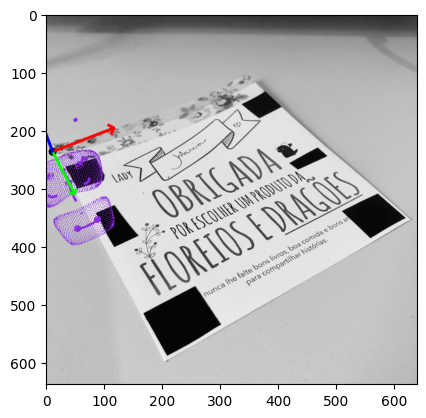

In [19]:
# Define a global coordinte frame to display on top of the image
object_points = 100*np.array([
    [0, 0, 0],
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]
], dtype=np.float64)


# Transpose object points
object_points =  object_points.T

# Define the distortion coefficients 
dist_coeffs = np.zeros((5, 1), np.float32) 


# Project the 3D points to the image plane using the camera matrices 
image_points, _ = cv2.projectPoints(object_points, R, t, K, dist_coeffs)

# Draw the projected points on the image
# rgb_image = cv2.cvtColor(frame0, cv2.COLOR_GRAY2RGB)

img = frame0

x0, y0 = image_points[0,0].astype(int)
print(f"({object_points[:,0]}) --> ({x0},{y0})\n")
cv2.circle(img, (x0, y0), 7, (0, 0, 0), -1)

x1, y1 = image_points[1,0].astype(int)
print(f"({object_points[:,1]}) --> ({x1},{y1})\n")
# Draw arrow
img = cv2.arrowedLine(img, (x0, y0), (x1, y1), (255, 0, 0), 4)  

x2, y2 = image_points[2,0].astype(int)
print(f"({object_points[:,2]}) --> ({x2},{y2})\n")
img = cv2.arrowedLine(img, (x0, y0), (x2, y2), (0, 255, 0), 4)  

x3, y3 = image_points[3,0].astype(int)
print(f"({object_points[:,3]}) --> ({x3},{y3})\n")
img = cv2.arrowedLine(img, (x0, y0), (x3, y3), (0, 0, 255), 4)  


# Display the image
plt.imshow(img)
plt.show()

# Test a top-view camera 

In [33]:
# Intrisics matrix (K) 
K = np.array([[800, 0, 350/2], 
              [0, 800, 371/2], 
              [0,   0,   1]])

print("K = \n", K)


# Extrinsic matrices 
# Matrix [R t] is the World-to-camera transformation. If we want to draw the camera, 
# we need to use the inverse matrix. 
R = np.array(
 [[1, 0,  0],
 [ 0, 1,  0 ],
 [ 0,  0,  1]], dtype=np.float64)
print("R = \n", R)

t = np.array(
 [[ -200,  0, 1000]], dtype=np.float64
)
print("\nt = \n", t)


print("\n")
# [ R t ] matrix 
Rt = np.block([[R, t.T]])
print("[R t] = \n", Rt)

K = 
 [[800.    0.  175. ]
 [  0.  800.  185.5]
 [  0.    0.    1. ]]
R = 
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

t = 
 [[-200.    0. 1000.]]


[R t] = 
 [[   1.    0.    0. -200.]
 [   0.    1.    0.    0.]
 [   0.    0.    1. 1000.]]


In [34]:
# Load reference image and convert it to gray scale
referenceImage = cv2.imread('../img/referenceImage.jpg', 0) 

referenceImage = cv2.cvtColor(referenceImage, cv2.COLOR_GRAY2RGB)


In [35]:
# Projection matrix (just the 3x4 submatrix)
P = K @ Rt

# project 3D object 
frame0 = []
frame0 = render(referenceImage, obj, P, referenceImage, True)

([0. 0. 0.]) --> (15,185)

([100.   0.   0.]) --> (95,185)

([  0. 100.   0.]) --> (15,265)

([  0.   0. 100.]) --> (29,185)



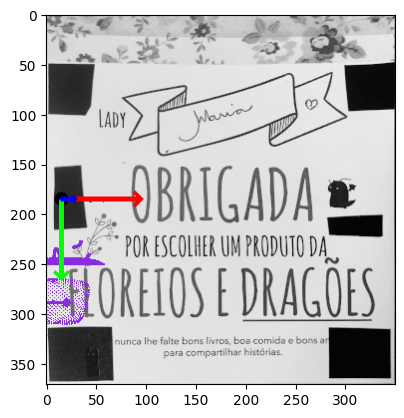

In [36]:
# Define a global coordinte frame to display on top of the image
object_points = 100*np.array([
    [0, 0, 0],
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]
], dtype=np.float64)


# Transpose object points
object_points =  object_points.T

# Define the distortion coefficients 
dist_coeffs = np.zeros((5, 1), np.float32) 


# Project the 3D points to the image plane using the camera matrices 
image_points, _ = cv2.projectPoints(object_points, R, t, K, dist_coeffs)

# Draw the projected points on the image
# rgb_image = cv2.cvtColor(frame0, cv2.COLOR_GRAY2RGB)

img = frame0

x0, y0 = image_points[0,0].astype(int)
print(f"({object_points[:,0]}) --> ({x0},{y0})\n")
cv2.circle(img, (x0, y0), 7, (0, 0, 0), -1)

x1, y1 = image_points[1,0].astype(int)
print(f"({object_points[:,1]}) --> ({x1},{y1})\n")
# Draw arrow
img = cv2.arrowedLine(img, (x0, y0), (x1, y1), (255, 0, 0), 4)  

x2, y2 = image_points[2,0].astype(int)
print(f"({object_points[:,2]}) --> ({x2},{y2})\n")
img = cv2.arrowedLine(img, (x0, y0), (x2, y2), (0, 255, 0), 4)  

x3, y3 = image_points[3,0].astype(int)
print(f"({object_points[:,3]}) --> ({x3},{y3})\n")
img = cv2.arrowedLine(img, (x0, y0), (x3, y3), (0, 0, 255), 4)  


# Display the image
plt.imshow(img)
plt.show()

In [37]:
# Load 3D model from OBJ file
# obj = OBJ('../models/f1200ab.obj')
obj = OBJ('../models/f1200ab.obj', swapyz=True)


FileNotFoundError: [Errno 2] No such file or directory: '../models/f1200ab.obj'

In [182]:
# Projection matrix (just the 3x4 submatrix)
P = K @ Rt

# project 3D object 
frame0 = []
frame0 = render(referenceImage, obj, P, referenceImage, True)

([0. 0. 0.]) --> (175,185)

([1000.    0.    0.]) --> (225,185)

([   0. 1000.    0.]) --> (175,235)

([   0.    0. 1000.]) --> (175,185)



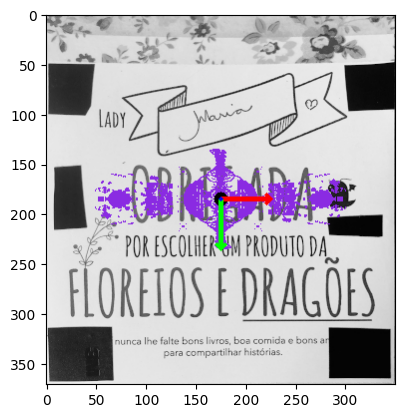

In [183]:
# Define a global coordinte frame to display on top of the image
object_points = 1000*np.array([
    [0, 0, 0],
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]
], dtype=np.float64)


# Transpose object points
object_points =  object_points.T

# Define the distortion coefficients 
dist_coeffs = np.zeros((5, 1), np.float32) 


# Project the 3D points to the image plane using the camera matrices 
image_points, _ = cv2.projectPoints(object_points, R, t, K, dist_coeffs)

# Draw the projected points on the image
# rgb_image = cv2.cvtColor(frame0, cv2.COLOR_GRAY2RGB)

img = frame0

x0, y0 = image_points[0,0].astype(int)
print(f"({object_points[:,0]}) --> ({x0},{y0})\n")
cv2.circle(img, (x0, y0), 7, (0, 0, 0), -1)

x1, y1 = image_points[1,0].astype(int)
print(f"({object_points[:,1]}) --> ({x1},{y1})\n")
# Draw arrow
img = cv2.arrowedLine(img, (x0, y0), (x1, y1), (255, 0, 0), 4)  

x2, y2 = image_points[2,0].astype(int)
print(f"({object_points[:,2]}) --> ({x2},{y2})\n")
img = cv2.arrowedLine(img, (x0, y0), (x2, y2), (0, 255, 0), 4)  

x3, y3 = image_points[3,0].astype(int)
print(f"({object_points[:,3]}) --> ({x3},{y3})\n")
img = cv2.arrowedLine(img, (x0, y0), (x3, y3), (0, 0, 255), 4)  


# Display the image
plt.imshow(img)
plt.show()

# Testing camera matrix from fSpy and Blender (Top view)

In [184]:
# Load the source image and convert it to gray scale
test_image = cv2.imread('../img/frame0.jpg') 

# From Blender
K = np.float32([[ 800,    0.,   360.],
                [   0., 800,   240.],
                [   0.,    0.,    1.]])

# Projection matrix (just the 3x4 submatrix)
P = K @ Rt

# project 3D object 
frame0 = []
frame0 = render(test_image, obj, P, test_image, True)




# Define a global coordinte frame to display on top of the image
object_points = 1000*np.array([
    [0, 0, 0],
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]
], dtype=np.float64)


# Transpose object points
object_points =  object_points.T

# Define the distortion coefficients 
dist_coeffs = np.zeros((5, 1), np.float32) 


# Project the 3D points to the image plane using the camera matrices 
image_points, _ = cv2.projectPoints(object_points, R, t, K, dist_coeffs)

# Draw the projected points on the image
# rgb_image = cv2.cvtColor(frame0, cv2.COLOR_GRAY2RGB)

img = frame0

x0, y0 = image_points[0,0].astype(int)
print(f"({object_points[:,0]}) --> ({x0},{y0})\n")
cv2.circle(img, (x0, y0), 7, (0, 0, 0), -1)

x1, y1 = image_points[1,0].astype(int)
print(f"({object_points[:,1]}) --> ({x1},{y1})\n")
# Draw arrow
img = cv2.arrowedLine(img, (x0, y0), (x1, y1), (255, 0, 0), 4)  

x2, y2 = image_points[2,0].astype(int)
print(f"({object_points[:,2]}) --> ({x2},{y2})\n")
img = cv2.arrowedLine(img, (x0, y0), (x2, y2), (0, 255, 0), 4)  

x3, y3 = image_points[3,0].astype(int)
print(f"({object_points[:,3]}) --> ({x3},{y3})\n")
img = cv2.arrowedLine(img, (x0, y0), (x3, y3), (0, 0, 255), 4)  

([0. 0. 0.]) --> (360,240)

([1000.    0.    0.]) --> (440,240)

([   0. 1000.    0.]) --> (360,320)

([   0.    0. 1000.]) --> (360,240)



In [185]:
R = np.float32([[0.9990788698196411, -0.006037485785782337, -0.04248487949371338],
        [0.008728401735424995, 0.9979474544525146, 0.06344063580036163],
        [-0.04201465845108032, -0.06375303119421005, -0.9970808625221252]
        ])


#T = np.float32([[0.9947172999382019, -1.0263903141021729, 8.166098594665527]])

T = np.float32([[0.6406684517860413, -8.118618965148926, 1.5510284900665283]])

print("K=\n", K)

print("R = \n", R)

print("\nT = \n", T)


print("\n")
# [ R t ] matrix 
Rt = np.block([[R, T.T]])
print("[R t] = \n", Rt)

K=
 [[800.   0. 360.]
 [  0. 800. 240.]
 [  0.   0.   1.]]
R = 
 [[ 0.99907887 -0.00603749 -0.04248488]
 [ 0.0087284   0.99794745  0.06344064]
 [-0.04201466 -0.06375303 -0.99708086]]

T = 
 [[ 0.64066845 -8.118619    1.5510285 ]]


[R t] = 
 [[ 9.9907887e-01 -6.0374858e-03 -4.2484879e-02  6.4066845e-01]
 [ 8.7284017e-03  9.9794745e-01  6.3440636e-02 -8.1186190e+00]
 [-4.2014658e-02 -6.3753031e-02 -9.9708086e-01  1.5510285e+00]]


In [186]:
# Projection matrix (just the 3x4 submatrix)
P = K @ Rt

# project 3D object 
frame0 = []
frame0 = render(test_image, obj, P, test_image, True)




# Define a global coordinte frame to display on top of the image
object_points = 1000*np.array([
    [0, 0, 0],
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]
], dtype=np.float64)


# Transpose object points
object_points =  object_points.T

# Define the distortion coefficients 
dist_coeffs = np.zeros((5, 1), np.float32) 


# Project the 3D points to the image plane using the camera matrices 
image_points, _ = cv2.projectPoints(object_points, R, t, K, dist_coeffs)

# Draw the projected points on the image
# rgb_image = cv2.cvtColor(frame0, cv2.COLOR_GRAY2RGB)

img = frame0

x0, y0 = image_points[0,0].astype(int)
print(f"({object_points[:,0]}) --> ({x0},{y0})\n")
cv2.circle(img, (x0, y0), 7, (0, 0, 0), -1)

x1, y1 = image_points[1,0].astype(int)
print(f"({object_points[:,1]}) --> ({x1},{y1})\n")
# Draw arrow
img = cv2.arrowedLine(img, (x0, y0), (x1, y1), (255, 0, 0), 4)  

x2, y2 = image_points[2,0].astype(int)
print(f"({object_points[:,2]}) --> ({x2},{y2})\n")
img = cv2.arrowedLine(img, (x0, y0), (x2, y2), (0, 255, 0), 4)  

x3, y3 = image_points[3,0].astype(int)
print(f"({object_points[:,3]}) --> ({x3},{y3})\n")
img = cv2.arrowedLine(img, (x0, y0), (x3, y3), (0, 0, 255), 4)  

([0. 0. 0.]) --> (360,240)

([1000.    0.    0.]) --> (440,240)

([   0. 1000.    0.]) --> (359,320)

([   0.    0. 1000.]) --> (356,245)



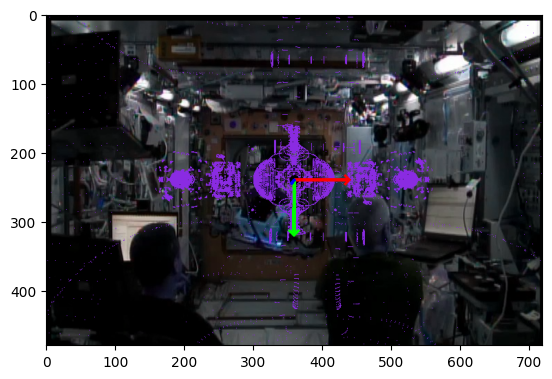

In [187]:
# Display the image
# img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

# Camera from Blender

In [ ]:
# Load the source image and convert it to gray scale
test_image = cv2.imread('../img/frame0.jpg') 

# From Blender
K = np.float32([[ 800,    0.,   360.],
                [   0., 800,   240.],
                [   0.,    0.,    1.]])

# Projection matrix (just the 3x4 submatrix)
P = K @ Rt

# project 3D object 
frame0 = []
frame0 = render(test_image, obj, P, test_image, True)




# Define a global coordinte frame to display on top of the image
object_points = 1000*np.array([
    [0, 0, 0],
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]
], dtype=np.float64)


# Transpose object points
object_points =  object_points.T

# Define the distortion coefficients 
dist_coeffs = np.zeros((5, 1), np.float32) 


# Project the 3D points to the image plane using the camera matrices 
image_points, _ = cv2.projectPoints(object_points, R, t, K, dist_coeffs)

# Draw the projected points on the image
# rgb_image = cv2.cvtColor(frame0, cv2.COLOR_GRAY2RGB)

img = frame0

x0, y0 = image_points[0,0].astype(int)
print(f"({object_points[:,0]}) --> ({x0},{y0})\n")
cv2.circle(img, (x0, y0), 7, (0, 0, 0), -1)

x1, y1 = image_points[1,0].astype(int)
print(f"({object_points[:,1]}) --> ({x1},{y1})\n")
# Draw arrow
img = cv2.arrowedLine(img, (x0, y0), (x1, y1), (255, 0, 0), 4)  

x2, y2 = image_points[2,0].astype(int)
print(f"({object_points[:,2]}) --> ({x2},{y2})\n")
img = cv2.arrowedLine(img, (x0, y0), (x2, y2), (0, 255, 0), 4)  

x3, y3 = image_points[3,0].astype(int)
print(f"({object_points[:,3]}) --> ({x3},{y3})\n")
img = cv2.arrowedLine(img, (x0, y0), (x3, y3), (0, 0, 255), 4)  


# Display the image
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.show()

[ WARN:0@3134.854] global loadsave.cpp:268 findDecoder imread_('../img/frame0.jpg'): can't open/read file: check file path/integrity


AttributeError: 'NoneType' object has no attribute 'shape'

In [114]:












# Projection matrix (just the 3x4 submatrix)








P1 = K @ Rt_new[:3,:4]


sourceImage = cv2.imread('../img/sourceImage_04.jpg', 0) 


# project cube or model
frame_plus = []
frame_plus = render(sourceImage, obj, P1[:3,:4], referenceImage, False)

# Show image
plt.figure(figsize=(12, 6))
plt.imshow(frame_plus, cmap='gray')
plt.show()

NameError: name 'Rt_new' is not defined

In [ ]:
# Decrease camera's z-coordinate to see effect
T_z_minus = np.array(
 [[1, 0,  0,  0],
  [0, 1,  0,  0],
  [0, 0,  1, -800],
  [0, 0,  0,  1]])

Rt_new = T_z_minus @ Rt
print("[R t] = \n", Rt_new)

In [ ]:
# Projection matrix (just the 3x4 submatrix)
P2 = K @ Rt_new[:3,:4]


sourceImage = cv2.imread('../img/sourceImage_04.jpg', 0) 

# project cube or model
frame_minus = []
frame_minus = render(sourceImage, obj, P2[:3,:4], referenceImage, False)

# Show image
plt.figure(figsize=(12, 6))
plt.imshow(frame_minus, cmap='gray')
plt.show()

In [ ]:
# Camera parameters
K2 = np.array([[4000, 0, 320], 
               [0, 4000, 240], 
               [0,    0,   1]])

In [ ]:
# Projection matrix (just the 3x4 submatrix)
P2 = K2 @ Rt_new[:3,:4]


sourceImage = cv2.imread('../img/sourceImage_04.jpg', 0) 

# project cube or model
frame_minus = []
frame_minus = render(sourceImage, obj, P2[:3,:4], referenceImage, False)

# Show image
plt.figure(figsize=(12, 6))
plt.imshow(frame_minus, cmap='gray')
plt.show()

In [ ]:
K3 = np.float32([[ 800,    0.,   240.],
                [   0., 800,     360.],
                [   0.,    0.,    1.]])

In [ ]:
R = np.float32([[-0.9990788698196411, -0.006037485785782337, 0.04248487949371338],
        [-0.008728401735424995, 0.9979474544525146, -0.06344063580036163],
        [-0.04201465845108032, -0.06375303119421005, -0.9970808625221252]])

print(R)

T = np.float32([[0.9947172999382019, -1.0263903141021729, 8.166098594665527]])
print(T)


Rt = np.block([
    [R,               T.T]])

print("\nCamera pose = \n", Rt)
print(Rt)

P = K3 @ Rt

print("\nProjection matrix = \n", P)

In [ ]:


sourceImage = cv2.imread('../img/sourceImage_04.jpg', 0) 

# project cube or model
frame_minus = []
frame_minus = render(sourceImage, obj, P[:3,:4], referenceImage, False)

# Show image
plt.figure(figsize=(12, 6))
plt.imshow(frame_minus, cmap='gray')
plt.show()